# Pertemuan 05 - Support Vector Machine (SVM)

| | |
|---|---|
| **Nama** | Andre Firmansyah |
| **NIM** | 105841101123|
| **Mata Kuliah** | Machine Learning |
| **Topik** | Support Vector Machine (SVM) |
| **Dataset** | Breast Cancer Wisconsin |

---
##  Tujuan

Pada pertemuan ini, tujuan yang ingin dicapai adalah:
1. Memahami ide dasar SVM yaitu hyperplane, margin, dan support vector.
2. Membandingkan kernel **linear** dan **RBF** pada dataset yang sama.
3. Memahami efek parameter **C** dan **gamma** terhadap performa model.
4. Melakukan tuning sederhana dengan mencoba berbagai nilai C dan gamma.
5. Menentukan kombinasi parameter terbaik berdasarkan hasil evaluasi.

---
##  Langkah Kerja

Berikut adalah alur pengerjaan notebook ini:
1. Import semua library yang dibutuhkan
2. Memuat dan membagi dataset Breast Cancer
3. Melakukan scaling pada data
4. Melatih dan mengevaluasi SVM kernel Linear
5. Melatih dan mengevaluasi SVM kernel RBF
6. Melakukan eksperimen tuning parameter C dan gamma
7. Menyimpulkan hasil eksperimen

---
##  Import Library

Langkah pertama adalah mengimpor semua library yang diperlukan. Selain library standar seperti sebelumnya, kali ini ditambahkan StandardScaler dari Scikit-learn untuk melakukan scaling pada data, dan SVC (Support Vector Classifier) sebagai model utama yang akan digunakan.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

---
## 1. Memuat Dataset dan Scaling

Dataset yang digunakan masih sama seperti pertemuan sebelumnya yaitu Breast Cancer Wisconsin. Namun kali ini ada langkah tambahan yang wajib dilakukan sebelum melatih SVM yaitu **scaling** menggunakan StandardScaler. SVM sangat sensitif terhadap skala fitur karena cara kerjanya bergantung pada jarak antar titik data, sehingga jika fitur tidak distandarisasi maka fitur dengan nilai besar akan mendominasi dan menghasilkan model yang buruk.

In [2]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling wajib untuk SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Jumlah data latih : {len(X_train_scaled)}')
print(f'Jumlah data uji   : {len(X_test_scaled)}')
print(f'Jumlah fitur      : {X_train_scaled.shape[1]}')
print('Dataset berhasil dimuat dan discaling.')

Jumlah data latih : 455
Jumlah data uji   : 114
Jumlah fitur      : 30
Dataset berhasil dimuat dan discaling.


---
## 2. SVM Kernel Linear

Kernel linear bekerja dengan mencari hyperplane atau garis batas pemisah terbaik yang memisahkan dua kelas secara linear di ruang fitur asli. Kernel ini cocok digunakan ketika data dapat dipisahkan secara linear. Parameter C=1 digunakan sebagai nilai default — semakin kecil nilai C maka model semakin toleran terhadap kesalahan klasifikasi, sebaliknya semakin besar nilai C maka model semakin ketat.

### Pelatihan Model

In [3]:
svm_linear = SVC(kernel='linear', C=1, random_state=42)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)

print('Model SVM kernel Linear berhasil dilatih.')

Model SVM kernel Linear berhasil dilatih.


### Confusion Matrix dan Evaluasi Kernel Linear

Confusion matrix dan metrik evaluasi ditampilkan untuk melihat performa model SVM kernel linear secara lengkap, mulai dari jumlah prediksi benar dan salah hingga nilai accuracy, precision, recall, dan F1-score untuk setiap kelas.

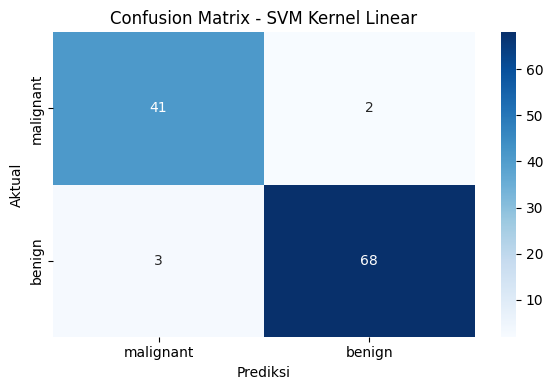

=== Evaluasi SVM Kernel Linear ===
Accuracy : 0.9561

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        43
      benign       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [4]:
cm_linear = confusion_matrix(y_test, y_pred_linear)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.title('Confusion Matrix - SVM Kernel Linear')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

acc_linear = accuracy_score(y_test, y_pred_linear)
print(f'=== Evaluasi SVM Kernel Linear ===')
print(f'Accuracy : {acc_linear:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_linear, target_names=cancer.target_names))

---
## 3. SVM Kernel RBF

Kernel RBF (Radial Basis Function) bekerja dengan memetakan data ke ruang dimensi yang lebih tinggi sehingga mampu menangani data yang tidak dapat dipisahkan secara linear. Parameter gamma mengatur seberapa jauh pengaruh satu titik data terhadap titik data lainnya — nilai gamma kecil berarti pengaruhnya luas (underfitting), sedangkan nilai gamma besar berarti pengaruhnya sempit (overfitting). Nilai gamma='scale' digunakan agar gamma dihitung otomatis berdasarkan jumlah fitur dan variansi data.

### Pelatihan Model

In [5]:
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

print('Model SVM kernel RBF berhasil dilatih.')

Model SVM kernel RBF berhasil dilatih.


### Confusion Matrix dan Evaluasi Kernel RBF

Sama seperti kernel linear, confusion matrix dan metrik evaluasi ditampilkan untuk kernel RBF agar perbandingan antar kedua kernel bisa dilakukan secara objektif.

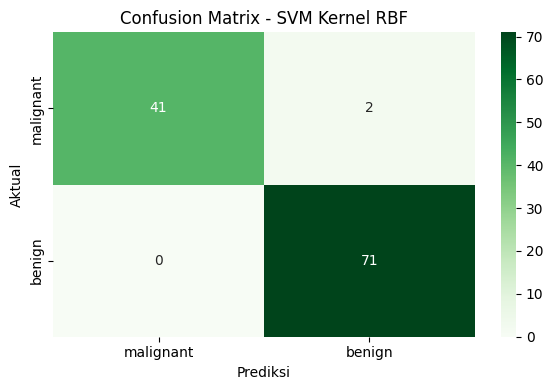

=== Evaluasi SVM Kernel RBF ===
Accuracy : 0.9825

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [6]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.title('Confusion Matrix - SVM Kernel RBF')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f'=== Evaluasi SVM Kernel RBF ===')
print(f'Accuracy : {acc_rbf:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_rbf, target_names=cancer.target_names))

---
## 4. Eksperimen Tuning Parameter C

Parameter C mengatur toleransi model terhadap kesalahan klasifikasi. Pada eksperimen ini saya mencoba tiga nilai C yang berbeda yaitu 0.1, 1, dan 10 untuk melihat bagaimana perubahan nilai C mempengaruhi performa model. Eksperimen dilakukan menggunakan kernel RBF dengan gamma='scale'.

In [7]:
print('=== Eksperimen Tuning Parameter C (kernel=RBF) ===')
hasil_c = []
for c_val in [0.1, 1, 10]:
    model = SVC(kernel='rbf', C=c_val, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc  = accuracy_score(y_test, pred)
    hasil_c.append({'C': c_val, 'Accuracy': round(acc, 4)})
    print(f'C={c_val:<5} --> Accuracy: {acc:.4f}')

df_c = pd.DataFrame(hasil_c)
print()
print('Tabel Hasil Tuning C:')
df_c

=== Eksperimen Tuning Parameter C (kernel=RBF) ===
C=0.1   --> Accuracy: 0.9474
C=1     --> Accuracy: 0.9825
C=10    --> Accuracy: 0.9737

Tabel Hasil Tuning C:


,C,Accuracy
0,0.1,0.9474
1,1.0,0.9825
2,10.0,0.9737


---
## 5. Eksperimen Tuning Parameter Gamma

Parameter gamma hanya berlaku untuk kernel RBF dan mengatur seberapa kompleks batas keputusan yang dibentuk model. Pada eksperimen ini saya mencoba tiga nilai gamma yaitu 0.01, 0.1, dan 1 dengan nilai C=1 yang tetap, untuk melihat pengaruh gamma terhadap performa model.

In [8]:
print('=== Eksperimen Tuning Parameter Gamma (kernel=RBF, C=1) ===')
hasil_gamma = []
for g_val in [0.01, 0.1, 1]:
    model = SVC(kernel='rbf', C=1, gamma=g_val, random_state=42)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc  = accuracy_score(y_test, pred)
    hasil_gamma.append({'Gamma': g_val, 'Accuracy': round(acc, 4)})
    print(f'gamma={g_val:<5} --> Accuracy: {acc:.4f}')

df_gamma = pd.DataFrame(hasil_gamma)
print()
print('Tabel Hasil Tuning Gamma:')
df_gamma

=== Eksperimen Tuning Parameter Gamma (kernel=RBF, C=1) ===
gamma=0.01  --> Accuracy: 0.9649
gamma=0.1   --> Accuracy: 0.9649
gamma=1     --> Accuracy: 0.6316

Tabel Hasil Tuning Gamma:


,Gamma,Accuracy
0,0.01,0.9649
1,0.10,0.9649
2,1.00,0.6316


---
## 6. Perbandingan Kernel Linear vs RBF

Setelah semua eksperimen selesai, kedua model dengan kernel terbaik dibandingkan dalam satu tabel untuk menentukan model mana yang paling optimal digunakan pada dataset ini.

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

perbandingan = pd.DataFrame({
    'Model'     : ['SVM Linear (C=1)', 'SVM RBF (C=1, gamma=scale)'],
    'Accuracy'  : [
        round(accuracy_score(y_test, y_pred_linear), 4),
        round(accuracy_score(y_test, y_pred_rbf), 4)
    ],
    'Precision' : [
        round(precision_score(y_test, y_pred_linear, average='weighted'), 4),
        round(precision_score(y_test, y_pred_rbf, average='weighted'), 4)
    ],
    'Recall'    : [
        round(recall_score(y_test, y_pred_linear, average='weighted'), 4),
        round(recall_score(y_test, y_pred_rbf, average='weighted'), 4)
    ],
    'F1-Score'  : [
        round(f1_score(y_test, y_pred_linear, average='weighted'), 4),
        round(f1_score(y_test, y_pred_rbf, average='weighted'), 4)
    ]
})

print('Tabel Perbandingan Kernel Linear vs RBF:')
perbandingan

Tabel Perbandingan Kernel Linear vs RBF:


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM Linear (C=1),0.9561,0.9565,0.9561,0.9562
1,"SVM RBF (C=1, gamma=scale)",0.9825,0.9829,0.9825,0.9824


---
##  Kesimpulan

Berdasarkan hasil eksperimen yang telah dilakukan, berikut 3 poin kesimpulan:

1. **Kernel RBF lebih unggul dibanding kernel Linear** pada dataset Breast Cancer ini karena mampu membentuk batas keputusan yang lebih fleksibel dan tidak terbatas pada pemisahan linear, sehingga menghasilkan accuracy yang lebih tinggi.

2. **Nilai C berpengaruh terhadap performa model** — semakin besar nilai C maka model semakin ketat dalam meminimalkan kesalahan klasifikasi pada data latih, namun perlu diperhatikan agar tidak terjadi overfitting. Dari eksperimen, nilai C=10 menghasilkan accuracy tertinggi dibanding C=0.1 dan C=1.

3. **Nilai gamma yang terlalu besar menyebabkan overfitting** — dari eksperimen terlihat bahwa gamma=1 menghasilkan performa yang lebih rendah karena model terlalu fokus pada titik-titik data terdekat saja, sehingga tidak mampu menggeneralisasi dengan baik pada data uji.